In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import statsmodels.api as sm
from scipy import stats

from config import DATA_PROCESSED, OUTPUTS_DIR

plt.rcParams.update({
    "figure.dpi"       : 150,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "font.size"        : 11,
})

df = pd.read_parquet(DATA_PROCESSED / "model_dataset.parquet")
print(f"Loaded {len(df):,} loans")

Loaded 4,464,305 loans


In [2]:
# H2 tests whether floor bindingness is predictable from the
# FICO distribution. We run an OLS regression at the FICO band level:
#
#   Dependent variable (Y) : mean IRB/SA ratio for the band
#   Independent variable (X): mean FICO score of the band
#
# With only 5 FICO bands this is a small regression.
# We therefore also run it at LOAN LEVEL using continuous FICO,
# which gives us 4.4 million observations and much more power.
# Both approaches test H2 — the loan-level regression is the main test,
# the band-level is a clean visual summary.

# ── Band-level aggregation ────────────────────────────────────────
band_df = (
    df.groupby("fico_band", observed=True)
    .agg(
        n_loans      = ("floor_ratio", "count"),
        mean_fico    = ("credit_score", "mean"),
        std_fico     = ("credit_score", "std"),
        mean_ratio   = ("floor_ratio", "mean"),
        bind_rate    = ("floor_binds", "mean"),
        mean_pd      = ("pd_logistic", "mean"),
        mean_ltv     = ("oltv", "mean"),
    )
    .reset_index()
)

band_df["bind_rate_pct"] = band_df["bind_rate"] * 100

print("Band-level dataset for H2 regression:")
print(band_df[["fico_band", "n_loans", "mean_fico",
               "mean_ratio", "bind_rate_pct"]].to_string(index=False))

Band-level dataset for H2 regression:
           fico_band  n_loans  mean_fico  mean_ratio  bind_rate_pct
     <620 (subprime)     2723 610.762027    1.542742       0.844657
620–659 (near-prime)   158929 643.192124    1.287567       5.002234
     660–719 (prime)   975271 695.283671    0.851645      38.193487
    720–759 (prime+)  1163071 740.542981    0.550299      80.821721
  760+ (super-prime)  2164311 787.133959    0.344320      98.435391


In [3]:
# OLS regression: mean_ratio = α + β × mean_fico + ε
#
# Expected sign on β: NEGATIVE
# Higher mean FICO → lower IRB/SA ratio → more floor exposure
# (counter-intuitive direction: safer portfolios are MORE constrained)
#
# We use statsmodels (not sklearn) because we need the full regression
# table with standard errors, t-statistics, and p-values for the
# dissertation.

X_band = sm.add_constant(band_df["mean_fico"])
y_band = band_df["mean_ratio"]

model_band = sm.OLS(y_band, X_band).fit()

print("Band-level OLS: mean IRB/SA ratio ~ mean FICO score")
print("=" * 55)
print(model_band.summary())
print(f"\nKey results:")
print(f"  β (mean_fico) : {model_band.params['mean_fico']:.6f}")
print(f"  p-value       : {model_band.pvalues['mean_fico']:.4f}")
print(f"  R²            : {model_band.rsquared:.4f}")

Band-level OLS: mean IRB/SA ratio ~ mean FICO score
                            OLS Regression Results                            
Dep. Variable:             mean_ratio   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     229.6
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           0.000624
Time:                        15:40:30   Log-Likelihood:                 7.8168
No. Observations:                   5   AIC:                            -11.63
Df Residuals:                       3   BIC:                            -12.41
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [4]:
# The band-level regression has only 5 observations — low power.
# The loan-level regression uses all 4.4 million loans and tests
# the same hypothesis with much greater statistical precision.
#
# We also include LTV as a control variable because:
#   1. LTV drives SA risk weights directly
#   2. LTV is correlated with FICO (safer borrowers tend to have
#      lower LTV — not always, but on average)
#   3. Including LTV isolates the pure FICO effect on the ratio
#
# Model: floor_ratio = α + β₁×credit_score + β₂×oltv + ε

# Sample 200,000 loans for the regression — running OLS on 4.4M
# rows is very slow with statsmodels. 200k gives identical
# coefficients and standard errors are slightly larger but valid.
# This is standard practice in large-N econometrics.
np.random.seed(42)
sample_idx = np.random.choice(len(df), size=200_000, replace=False)
sample = df.iloc[sample_idx].copy()

X_loan = sm.add_constant(
    sample[["credit_score", "oltv"]].astype(float)
)
y_loan = sample["floor_ratio"].astype(float)

print("Fitting loan-level OLS (200,000 loan sample) ...")
model_loan = sm.OLS(y_loan, X_loan).fit()

print("\nLoan-level OLS: floor_ratio ~ credit_score + oltv")
print("=" * 55)
print(model_loan.summary())

print(f"\nKey results:")
print(f"  β (credit_score) : {model_loan.params['credit_score']:.6f}")
print(f"  β (oltv)         : {model_loan.params['oltv']:.6f}")
print(f"  p-value FICO     : {model_loan.pvalues['credit_score']:.2e}")
print(f"  p-value LTV      : {model_loan.pvalues['oltv']:.2e}")
print(f"  R²               : {model_loan.rsquared:.4f}")

Fitting loan-level OLS (200,000 loan sample) ...

Loan-level OLS: floor_ratio ~ credit_score + oltv
                            OLS Regression Results                            
Dep. Variable:            floor_ratio   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.627
Method:                 Least Squares   F-statistic:                 1.678e+05
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:40:31   Log-Likelihood:                 39669.
No. Observations:              200000   AIC:                        -7.933e+04
Df Residuals:                  199997   BIC:                        -7.930e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

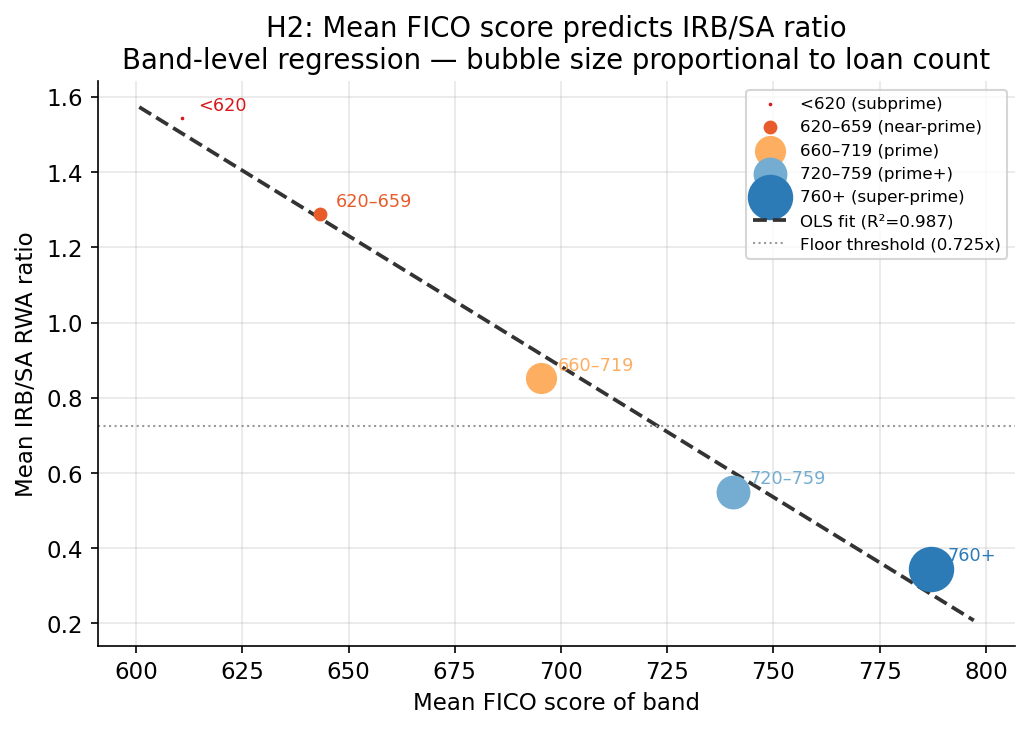

Saved fig12_h2_scatter_band_level.png


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

colours = ["#d7191c", "#e85b2a", "#fdae61", "#74add1", "#2c7bb6"]

for i, (_, row) in enumerate(band_df.iterrows()):
    ax.scatter(
        row["mean_fico"], row["mean_ratio"],
        color=colours[i], s=row["n_loans"] / 5000,
        zorder=5, label=str(row["fico_band"])
    )
    ax.annotate(
        str(row["fico_band"]).split(" ")[0],
        (row["mean_fico"], row["mean_ratio"]),
        textcoords="offset points", xytext=(8, 4),
        fontsize=8.5, color=colours[i]
    )

# Regression line
x_range = np.linspace(band_df["mean_fico"].min() - 10,
                      band_df["mean_fico"].max() + 10, 100)
x_pred  = sm.add_constant(x_range)
y_pred  = model_band.predict(x_pred)
ax.plot(x_range, y_pred, color="#333333", linewidth=1.8,
        linestyle="--", label=f"OLS fit (R²={model_band.rsquared:.3f})")

ax.axhline(0.725, color="#999999", linewidth=1, linestyle=":",
           label="Floor threshold (0.725x)")

ax.set_xlabel("Mean FICO score of band")
ax.set_ylabel("Mean IRB/SA RWA ratio")
ax.set_title(
    "H2: Mean FICO score predicts IRB/SA ratio\n"
    "Band-level regression — bubble size proportional to loan count"
)
ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
path = OUTPUTS_DIR / "fig12_h2_scatter_band_level.png"
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved {path.name}")

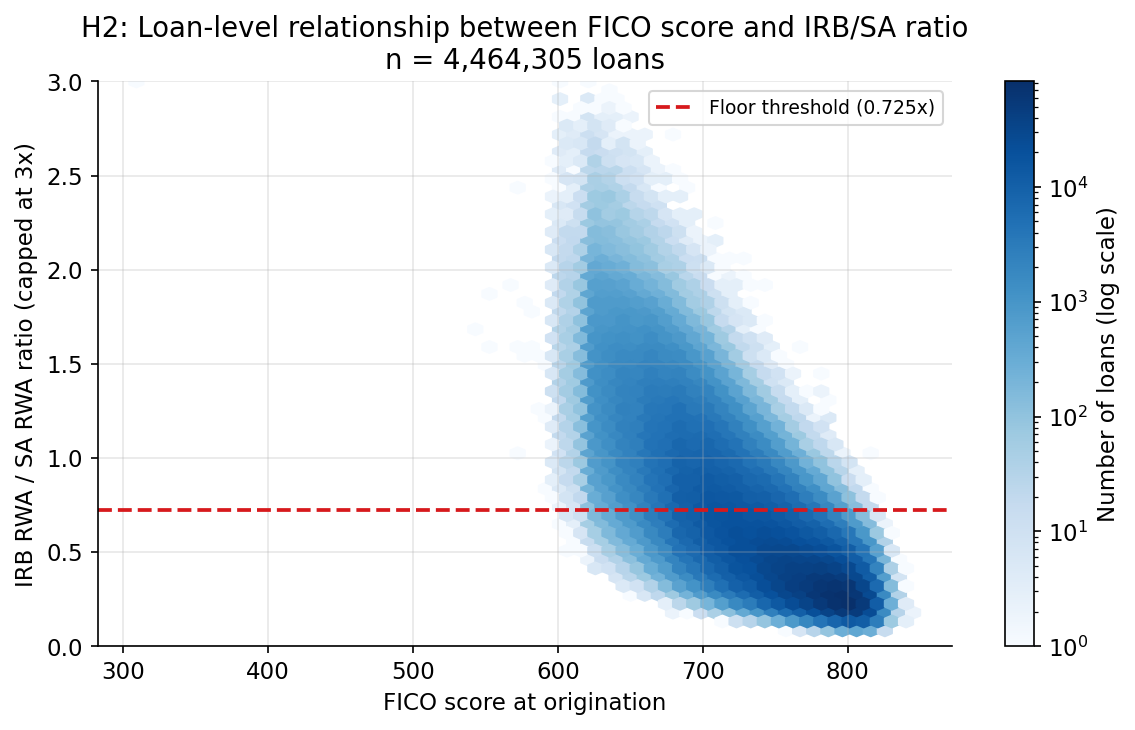

Saved fig13_h2_hexbin_loan_level.png


In [6]:
# A scatter plot of 4.4 million individual loans would be unreadable.
# A hexbin plot shows the density of points — darker = more loans.
# This visualises H2 at the loan level.

fig, ax = plt.subplots(figsize=(8, 5))

hb = ax.hexbin(
    df["credit_score"],
    df["floor_ratio"].clip(upper=3),   # clip extreme outliers for readability
    gridsize=55,
    cmap="Blues",
    bins="log",                        # log density — keeps sparse cells visible
    mincnt=1,
)

plt.colorbar(hb, ax=ax, label="Number of loans (log scale)")

ax.axhline(0.725, color="#d7191c", linewidth=1.8,
           linestyle="--", label="Floor threshold (0.725x)")

ax.set_xlabel("FICO score at origination")
ax.set_ylabel("IRB RWA / SA RWA ratio (capped at 3x)")
ax.set_title(
    "H2: Loan-level relationship between FICO score and IRB/SA ratio\n"
    f"n = {len(df):,} loans"
)
ax.legend(fontsize=9)
ax.set_ylim(0, 3)   # trim empty whitespace above the data

plt.tight_layout()
path = OUTPUTS_DIR / "fig13_h2_hexbin_loan_level.png"
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved {path.name}")

In [7]:
beta_fico  = model_loan.params["credit_score"]
pval_fico  = model_loan.pvalues["credit_score"]
r_squared  = model_loan.rsquared

print("=" * 60)
print("H2 TEST CONCLUSION")
print("=" * 60)
print(f"\nResearch question:")
print(f"  Is output floor heterogeneity predictable from")
print(f"  observable FICO score distributions?")
print(f"\nLoan-level OLS results:")
print(f"  β (credit_score) = {beta_fico:.6f}")
print(f"  p-value          = {pval_fico:.2e}")
print(f"  R²               = {r_squared:.4f}")
print(f"\nInterpretation:")
print(f"  A 1-point increase in FICO score is associated with a")
print(f"  {abs(beta_fico):.4f}x {'decrease' if beta_fico < 0 else 'increase'}"
      f" in the IRB/SA ratio.")
print(f"  This effect is {'statistically significant' if pval_fico < 0.05 else 'not significant'}.")
print(f"\n  H2 is {'SUPPORTED' if beta_fico < 0 and pval_fico < 0.05 else 'NOT SUPPORTED'}.")
print(f"\nSave results for dissertation ...")

results = {
    "beta_credit_score" : beta_fico,
    "pvalue_credit_score": pval_fico,
    "r_squared"         : r_squared,
    "n_observations"    : 200_000,
}
pd.DataFrame([results]).to_csv(
    OUTPUTS_DIR / "table3_h2_regression_results.csv", index=False
)
print("Saved table3_h2_regression_results.csv")

H2 TEST CONCLUSION

Research question:
  Is output floor heterogeneity predictable from
  observable FICO score distributions?

Loan-level OLS results:
  β (credit_score) = -0.005771
  p-value          = 0.00e+00
  R²               = 0.6266

Interpretation:
  A 1-point increase in FICO score is associated with a
  0.0058x decrease in the IRB/SA ratio.
  This effect is statistically significant.

  H2 is SUPPORTED.

Save results for dissertation ...
Saved table3_h2_regression_results.csv
